# Amazon Domain EDA

Explores raw data from `FR_Monthly_NaturalVeg_2000_2024_v16.csv` before any preprocessing.

**Goals:**
1. Confirm columns of interest match `amazon_description.md`
2. Understand station coverage, time period, and data availability
3. Explore distributions, seasonal patterns, and predictor–target correlations
4. Flag data quality issues to inform preprocessing decisions

In [1]:
import sys
import warnings
from pathlib import Path

import gcsfs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.9)

root = Path.cwd()
while root != root.parent and not (root / "CLAUDE.md").exists():
    root = root.parent
if not (root / "CLAUDE.md").exists():
    raise RuntimeError("Project root not found — launch Jupyter from inside the repo.")
sys.path.insert(0, str(root))

from config.config import load_config

cfg    = load_config("amazon_domain")
BUCKET = cfg["gcs"]["bucket"]
FILES  = cfg["gcs"]["files"]

print("Project root:", root)
print("Bucket      :", BUCKET)

Project root: c:\Sandeep\Woodwell\Multi-domain-time-series
Bucket      : gs://fr_v1/am_hydro_fire_risk_V2


In [2]:
flags: list[str] = []

fs           = gcsfs.GCSFileSystem(token="google_default")
primary_path = f"{BUCKET}/{FILES['fire_risk_monthly']}"
station_path = f"{BUCKET}/{FILES['station_list']}"

print(f"Loading: {primary_path}")
with fs.open(primary_path) as f:
    df_raw = pd.read_csv(f)

print(f"Loading: {station_path}")
with fs.open(station_path) as f:
    stations = pd.read_csv(f)

print(f"\nPrimary file — shape : {df_raw.shape}")
print(f"Station list — shape : {stations.shape}")

Loading: gs://fr_v1/am_hydro_fire_risk_V2/FR_Monthly_NaturalVeg_2000_2024_v16.csv
Loading: gs://fr_v1/am_hydro_fire_risk_V2/ANA_StationList_filteredAF_nov2025.csv

Primary file — shape : (48264, 24)
Station list — shape : (98, 2)


In [3]:
COLS_INTEREST = ["EstacaoCod", "year", "month", "Prec", "tmax", "tmin", "ET", "vpd", "DrangAr", "vazao", "AF", "BA"]
PREDICTORS    = ["Prec", "tmax", "tmin", "ET", "vpd", "DrangAr"]
TARGETS       = ["vazao", "AF", "BA"]

print("All columns in raw file:")
print(df_raw.columns.tolist())

missing_cols = [c for c in COLS_INTEREST if c not in df_raw.columns]
if missing_cols:
    msg = f"FLAG: Columns not found in raw CSV: {missing_cols}"
    flags.append(msg)
    print(f"\n*** {msg} ***")

avail = [c for c in COLS_INTEREST if c in df_raw.columns]
print(f"\nSample rows ({len(avail)}/{len(COLS_INTEREST)} columns of interest available):")
display(df_raw[avail].head(3))

if not missing_cols:
    print("\nAll 12 columns of interest present ✓")

if "x" not in stations.columns:
    msg = "FLAG: Column 'x' not found in station list file."
    flags.append(msg)
    print(f"*** {msg} ***")
else:
    print(f"Station list 'x' column present — {stations['x'].nunique()} unique IDs ✓")

All columns in raw file:
['Unnamed: 0', 'EstacaoCod', 'year', 'month', 'vazao', 'mean', 'sd', 'Vanom', 'Vcumanom', 'Vcumanom2', 'VcumDef', 'AF', 'bright', 'frp', 'BA', 'Prec', 'ET', 'vpd', 'tmax', 'tmin', 'pdsi', 'DrangAr', 'ana', 'date']

Sample rows (12/12 columns of interest available):


,EstacaoCod,year,month,Prec,tmax,tmin,ET,vpd,DrangAr,vazao,AF,BA
0,10075000,2000,1,39892.35870,26.244348,15.353848,22608.89731,0.687088,710159.0,21913.87097,0,0.000000
1,10075000,2000,10,26118.54753,27.565051,15.161922,26439.94699,0.795674,710159.0,17113.22581,0,0.000000
2,10075000,2000,11,29812.34964,27.709672,15.672908,25032.06147,0.787947,710159.0,15707.00000,749,118.500358



All 12 columns of interest present ✓
Station list 'x' column present — 98 unique IDs ✓


## 1. Station & Time Coverage

In [4]:
valid_stations = set(stations["x"].astype(str))
df = df_raw[COLS_INTEREST].copy()

n_before = df["EstacaoCod"].nunique()
df       = df[df["EstacaoCod"].astype(str).isin(valid_stations)].copy()
n_after  = df["EstacaoCod"].nunique()

print(f"Stations in primary file  : {n_before}")
print(f"IDs in station allowlist  : {len(valid_stations)}")
print(f"Stations after filtering  : {n_after}")

if n_before != n_after:
    flags.append(f"FLAG: {n_before - n_after} stations in primary file excluded by allowlist.")

print(f"\nYear range  : {int(df['year'].min())} – {int(df['year'].max())}")
print(f"Month range : {int(df['month'].min())} – {int(df['month'].max())}")
print(f"Total rows  : {len(df):,}")

Stations in primary file  : 198
IDs in station allowlist  : 98
Stations after filtering  : 98

Year range  : 2000 – 2024
Month range : 1 – 12
Total rows  : 25,836


## 2. Missing Values

,missing_count,missing_pct
EstacaoCod,0,0.00
year,0,0.00
month,0,0.00
Prec,0,0.00
tmax,0,0.00
tmin,0,0.00
ET,0,0.00
vpd,0,0.00
DrangAr,0,0.00
vazao,1630,6.31


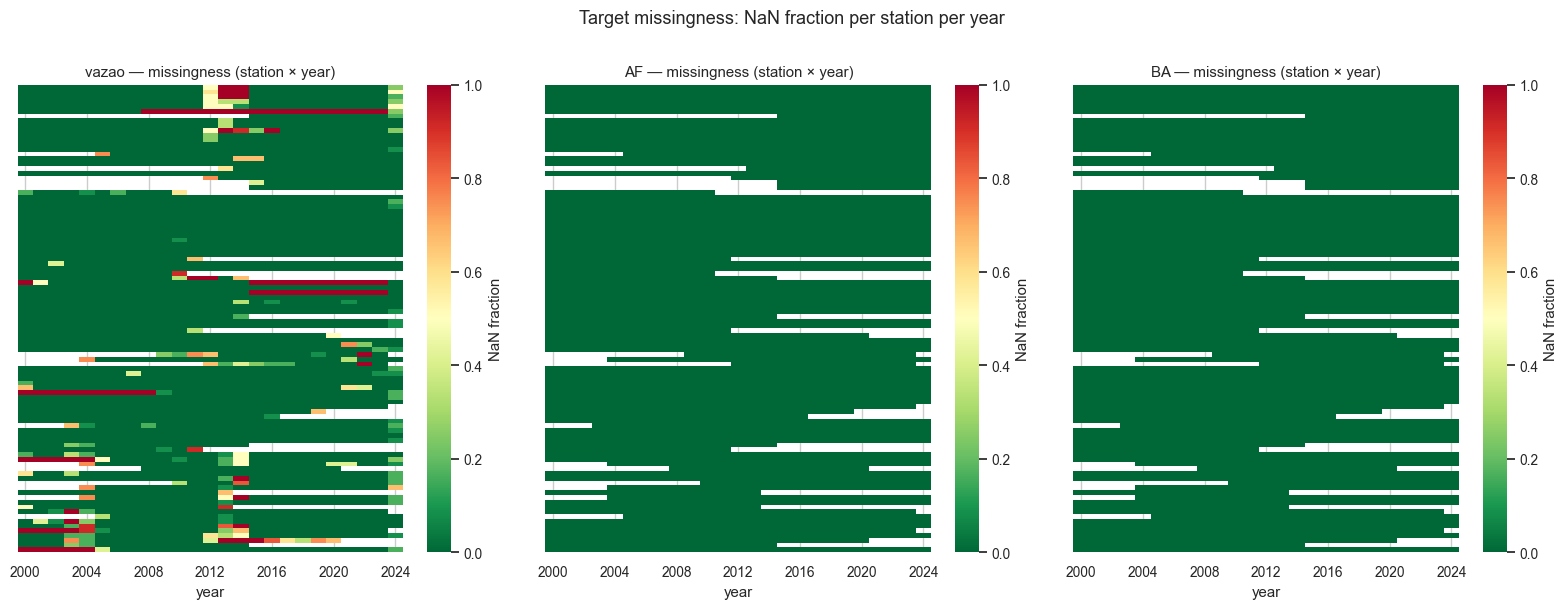

In [5]:
miss_pct   = df[COLS_INTEREST].isnull().mean().mul(100).round(2)
miss_count = df[COLS_INTEREST].isnull().sum()
miss_df    = pd.DataFrame({"missing_count": miss_count, "missing_pct": miss_pct})
display(miss_df)

for col, pct in miss_pct.items():
    if pct > 20:
        flags.append(f"FLAG: '{col}' has {pct:.1f}% missing values — review before preprocessing.")

# Heatmap: NaN fraction per station per year, one panel per target
fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 6))
for ax, col in zip(axes, TARGETS):
    pivot = df.pivot_table(
        index="EstacaoCod", columns="year", values=col,
        aggfunc=lambda x: x.isnull().mean()
    )
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=1,
                cbar_kws={"label": "NaN fraction"}, xticklabels=4, yticklabels=False)
    ax.set_title(f"{col} — missingness (station × year)")
    ax.set_xlabel("year")
    ax.set_ylabel("")

plt.suptitle("Target missingness: NaN fraction per station per year", y=1.01)
plt.tight_layout()
plt.show()

## 3. Distributions

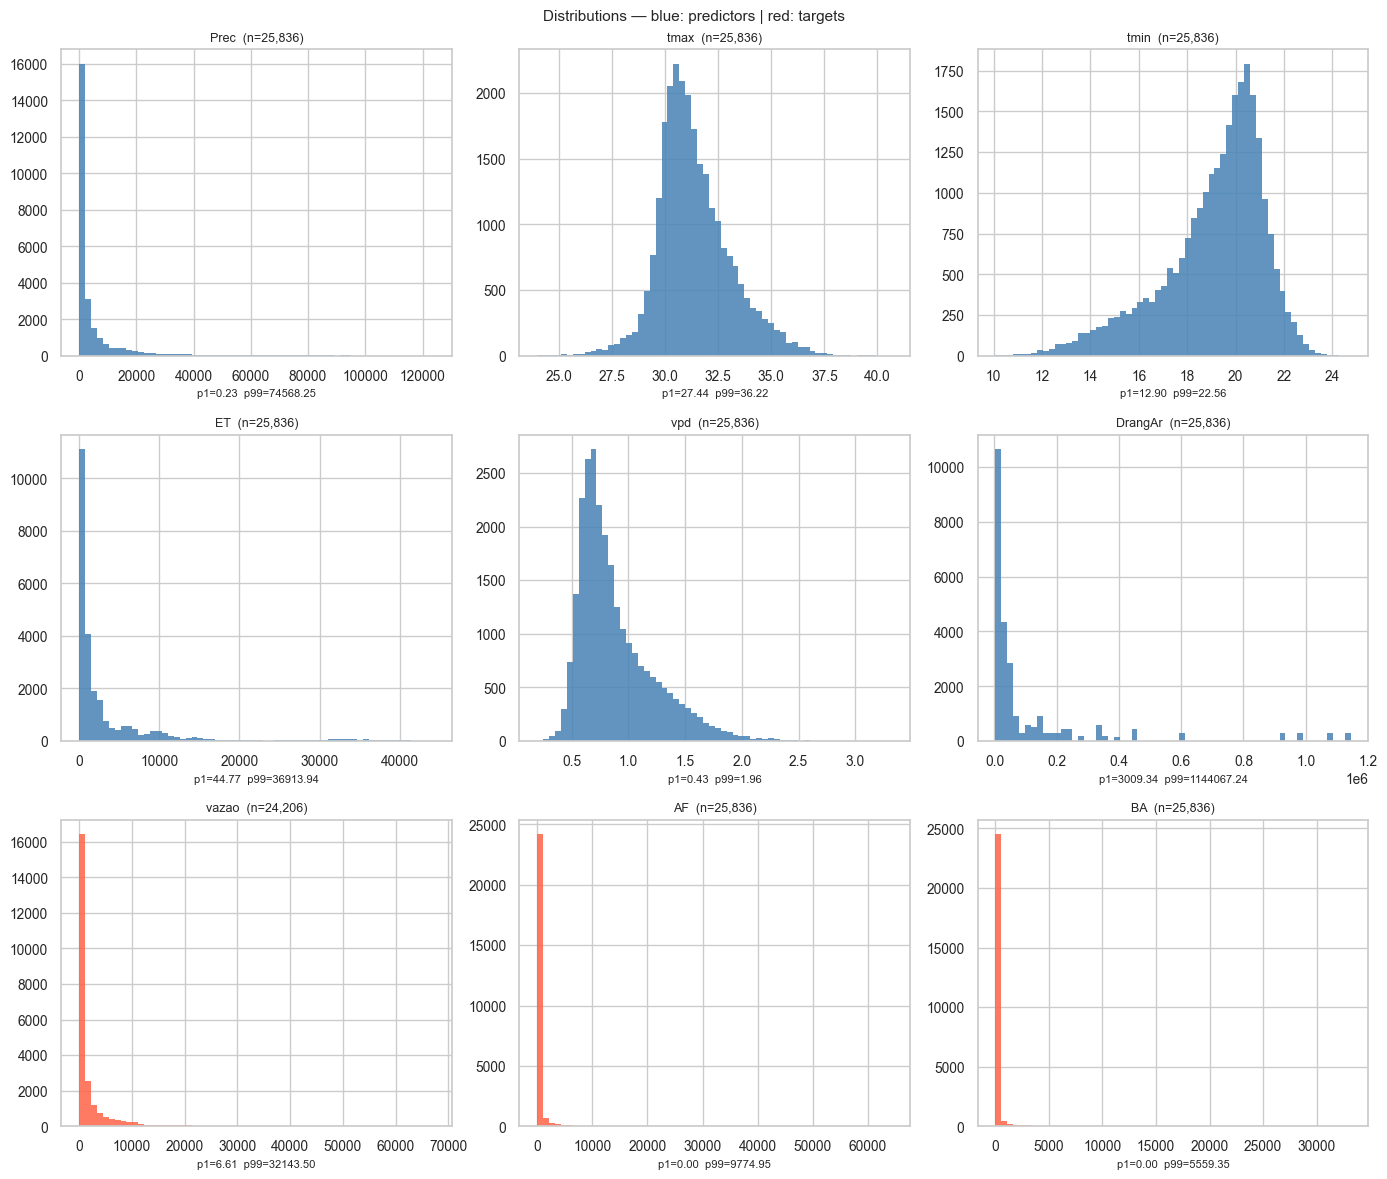

In [6]:
all_vars = PREDICTORS + TARGETS
ncols    = 3
nrows    = (len(all_vars) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, all_vars):
    data  = df[col].dropna()
    color = "steelblue" if col in PREDICTORS else "tomato"
    ax.hist(data, bins=60, color=color, edgecolor="none", alpha=0.85)
    q01, q99 = data.quantile(0.01), data.quantile(0.99)
    ax.set_title(f"{col}  (n={len(data):,})", fontsize=9)
    ax.set_xlabel(f"p1={q01:.2f}  p99={q99:.2f}", fontsize=8)
    if q99 > 0 and q01 >= 0 and q99 > max(q01 * 1000, 1):
        flags.append(f"FLAG: '{col}' extreme value spread (p1={q01:.2f}, p99={q99:.2f}) — check for outliers.")

for ax in axes[len(all_vars):]:
    ax.axis("off")

plt.suptitle("Distributions — blue: predictors | red: targets", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Time Series — Sample Stations

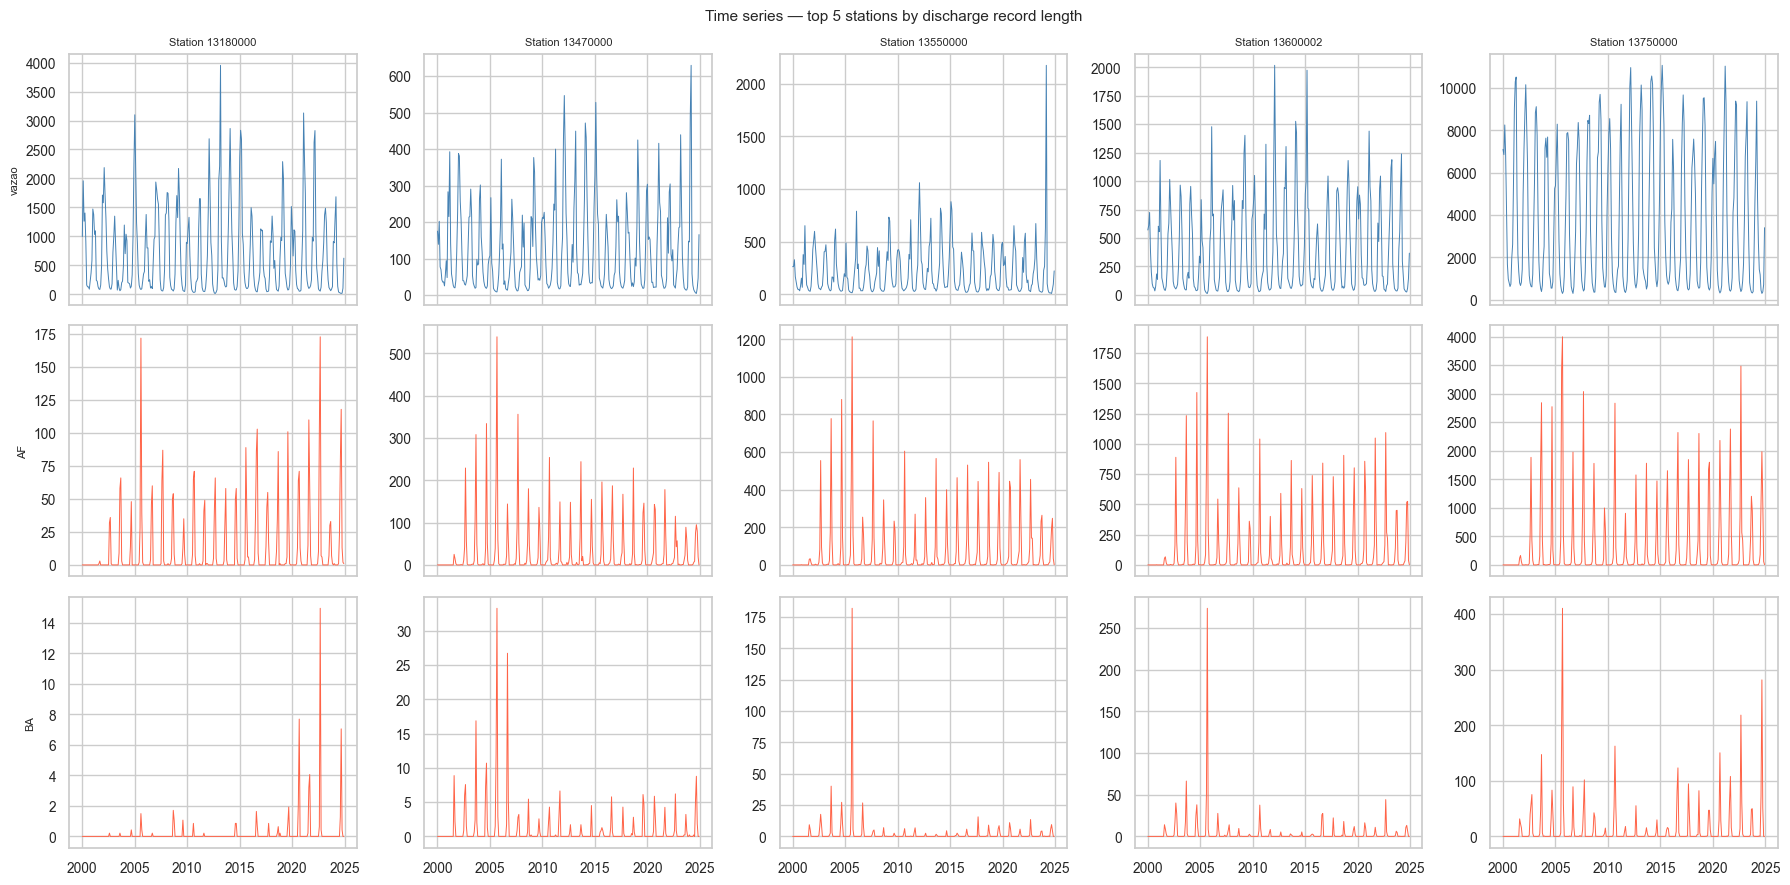

In [7]:
top5 = (
    df.groupby("EstacaoCod")["vazao"]
    .count()
    .nlargest(5)
    .index.tolist()
)

fig, axes = plt.subplots(len(TARGETS), len(top5), figsize=(18, 9), sharex="col")

for col_idx, sid in enumerate(top5):
    sdf = df[df["EstacaoCod"] == sid].sort_values(["year", "month"])
    sdf = sdf.assign(time=sdf["year"] + (sdf["month"] - 1) / 12)
    for row_idx, col in enumerate(TARGETS):
        ax    = axes[row_idx, col_idx]
        color = "steelblue" if col == "vazao" else "tomato"
        ax.plot(sdf["time"], sdf[col], linewidth=0.7, color=color)
        if row_idx == 0:
            ax.set_title(f"Station {sid}", fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(col, fontsize=8)

plt.suptitle("Time series — top 5 stations by discharge record length", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Seasonal Patterns

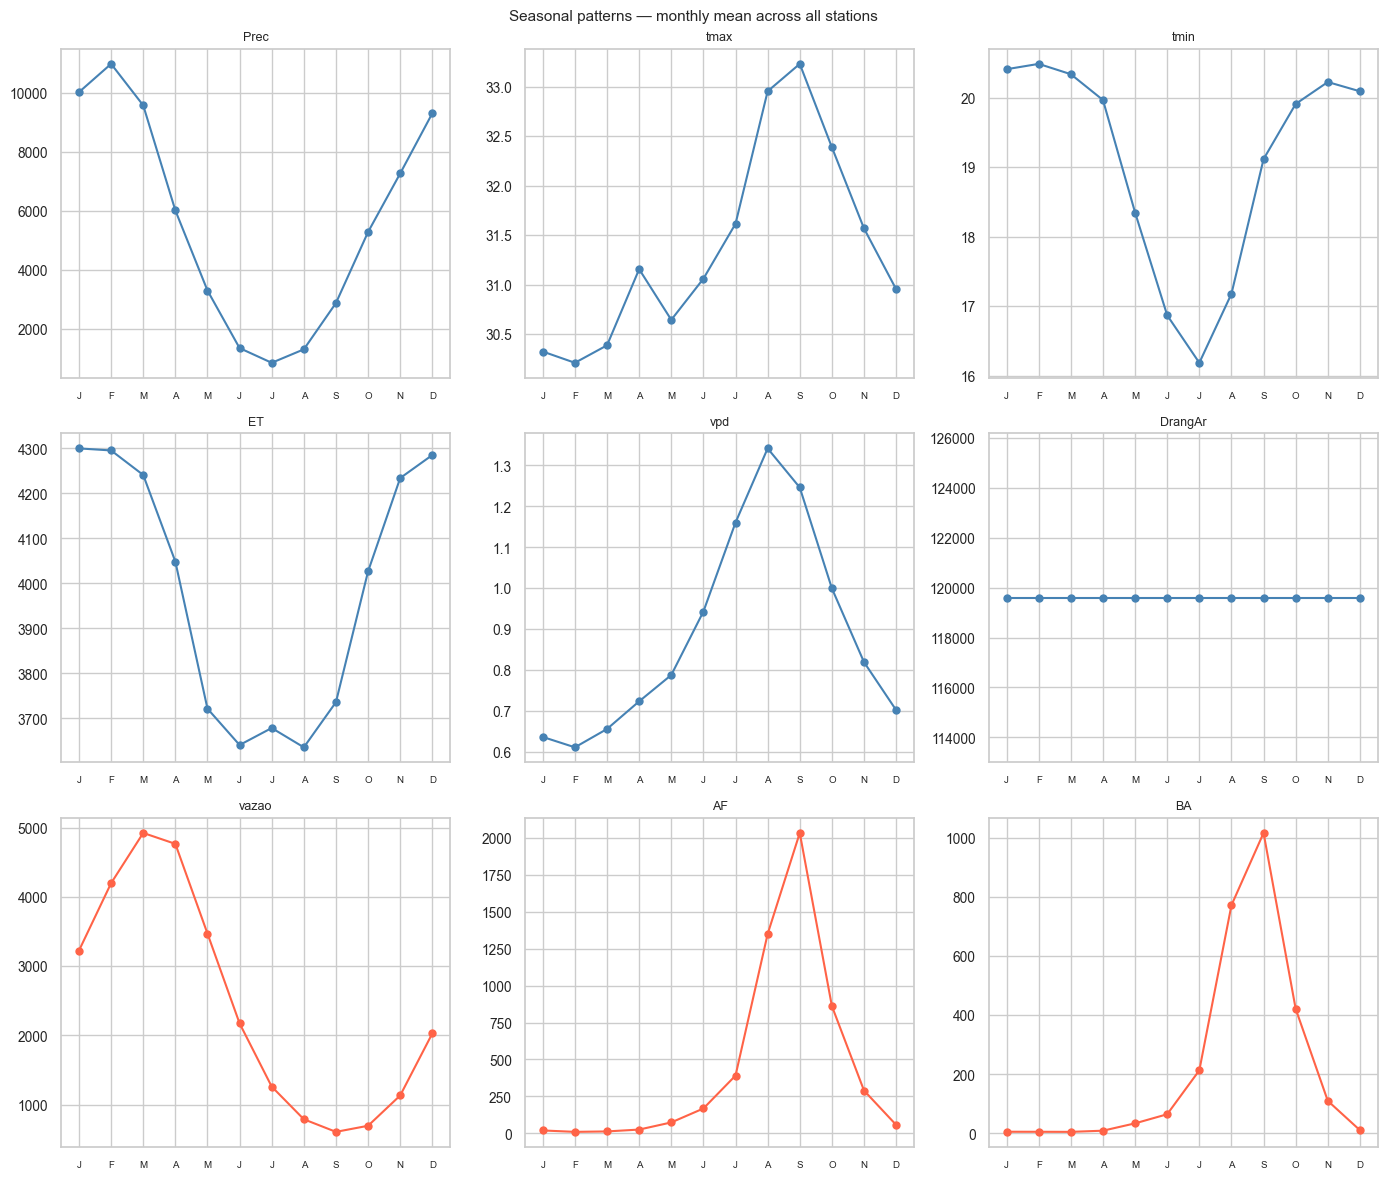

In [8]:
seasonal  = df.groupby("month")[PREDICTORS + TARGETS].mean()
all_vars  = PREDICTORS + TARGETS
ncols     = 3
nrows     = (len(all_vars) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

for ax, col in zip(axes, all_vars):
    color = "steelblue" if col in PREDICTORS else "tomato"
    ax.plot(seasonal.index, seasonal[col], marker="o", linewidth=1.5, markersize=5, color=color)
    ax.set_title(col, fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=7)

for ax in axes[len(all_vars):]:
    ax.axis("off")

plt.suptitle("Seasonal patterns — monthly mean across all stations", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Correlation Matrix

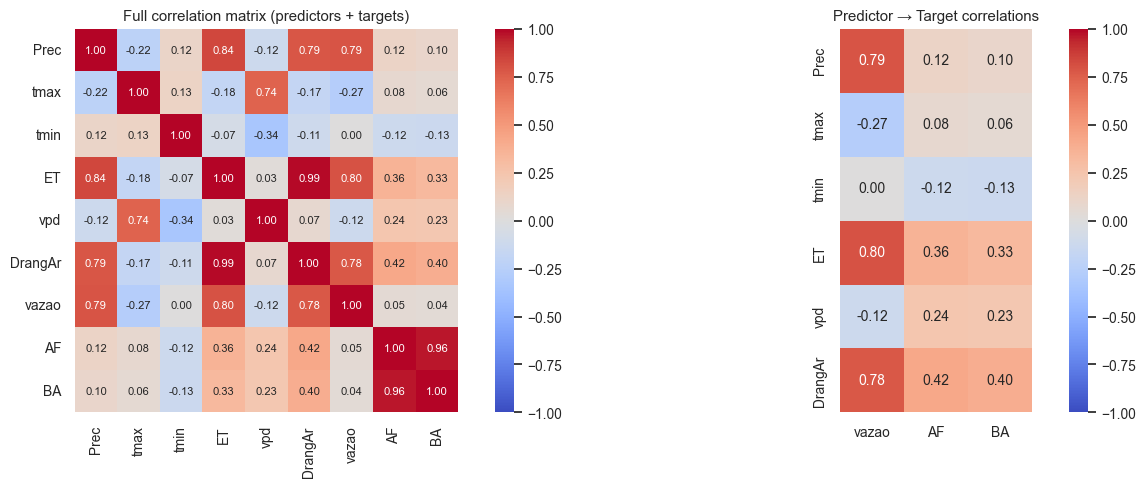

In [9]:
corr = df[PREDICTORS + TARGETS].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, ax=axes[0], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, square=True)
axes[0].set_title("Full correlation matrix (predictors + targets)")

pred_target = corr.loc[PREDICTORS, TARGETS]
sns.heatmap(pred_target, ax=axes[1], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 10}, square=True)
axes[1].set_title("Predictor → Target correlations")

plt.tight_layout()
plt.show()

## 7. Station-Level Completeness

Stations with 100% completeness (2000–2024) : 64
Stations with <50% completeness              : 10

Completeness summary:


,pct_complete
count,98.000000
mean,87.877551
std,19.850610
min,40.000000
25%,84.000000
50%,100.000000
75%,100.000000
max,100.000000


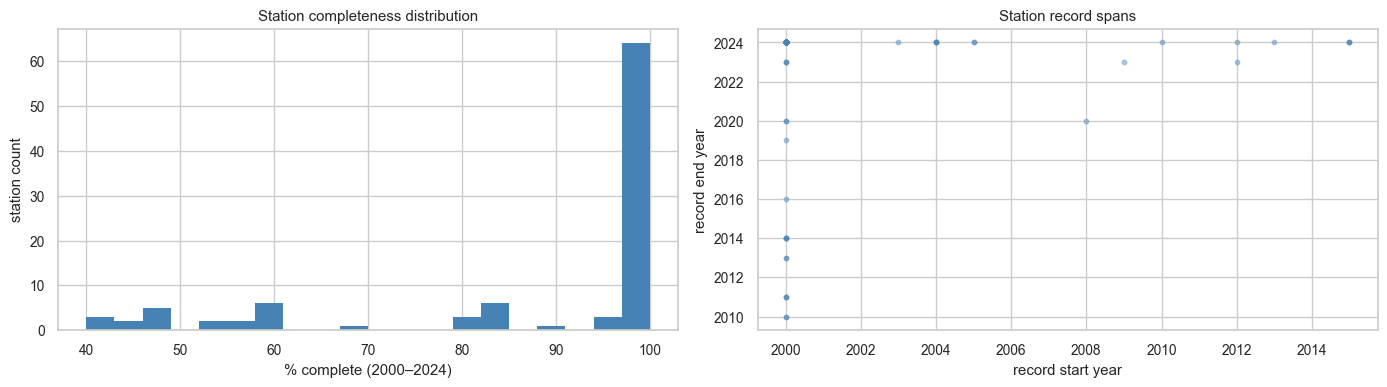

In [10]:
EXPECTED_MONTHS = 25 * 12  # 2000–2024

station_stats = []
for sid, grp in df.groupby("EstacaoCod"):
    actual_keys = set(zip(grp["year"], grp["month"]))
    n_actual    = len(actual_keys)
    station_stats.append({
        "station_id":       sid,
        "n_records":        n_actual,
        "n_missing_months": EXPECTED_MONTHS - n_actual,
        "pct_complete":     round(n_actual / EXPECTED_MONTHS * 100, 1),
        "year_start":       int(grp["year"].min()),
        "year_end":         int(grp["year"].max()),
    })

stats_df = pd.DataFrame(station_stats).sort_values("pct_complete")

print(f"Stations with 100% completeness (2000–2024) : {(stats_df['pct_complete'] == 100).sum()}")
print(f"Stations with <50% completeness              : {(stats_df['pct_complete'] < 50).sum()}")
print("\nCompleteness summary:")
display(stats_df["pct_complete"].describe().to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(stats_df["pct_complete"], bins=20, color="steelblue", edgecolor="none")
axes[0].set_xlabel("% complete (2000–2024)")
axes[0].set_ylabel("station count")
axes[0].set_title("Station completeness distribution")

axes[1].scatter(stats_df["year_start"], stats_df["year_end"], alpha=0.4, s=10, color="steelblue")
axes[1].set_xlabel("record start year")
axes[1].set_ylabel("record end year")
axes[1].set_title("Station record spans")

plt.tight_layout()
plt.show()

low = stats_df[stats_df["pct_complete"] < 50]
if len(low) > 0:
    flags.append(f"FLAG: {len(low)} stations have <50% completeness (2000–2024) — review whether to include in training.")

## 8. Summary Statistics Table

In [11]:
summary = df[COLS_INTEREST].describe().T
summary["missing_pct"] = df[COLS_INTEREST].isnull().mean().mul(100).round(2)
summary = summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "missing_pct"]]
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 15)
display(summary)

,count,mean,std,min,25%,50%,75%,max,missing_pct
EstacaoCod,25836.000,15754390.896,2046635.860,12370000.000,13710001.000,15750000.000,17380000.000,18880000.000,0.000
year,25836.000,2011.921,7.085,2000.000,2006.000,2012.000,2018.000,2024.000,0.000
month,25836.000,6.500,3.452,1.000,3.750,6.500,9.250,12.000,0.000
Prec,25836.000,5679.366,12901.327,0.000,275.679,1081.422,4442.180,124086.126,0.000
tmax,25836.000,31.374,1.726,23.984,30.257,31.104,32.315,40.702,0.000
tmin,25836.000,19.094,2.113,10.076,18.049,19.597,20.574,24.754,0.000
ET,25836.000,3987.101,7446.392,1.962,298.445,1024.872,3684.407,44288.228,0.000
vpd,25836.000,0.886,0.339,0.197,0.647,0.785,1.045,3.327,0.000
DrangAr,25836.000,119585.502,230533.002,3009.344,11058.458,34533.256,110145.803,1144067.236,0.000
vazao,24206.000,2443.517,5740.352,0.000,117.075,435.641,1744.841,67309.571,6.310


## 9. Flags & Decisions Needed

All issues detected automatically during EDA. Each **FLAG** should be resolved and recorded
in the `EDA Results & Decisions` section of `amazon_description.md` before proceeding to `01_preprocess.py`.

In [12]:
print(f"{len(flags)} flag(s) raised:\n")
for i, flag_msg in enumerate(flags, 1):
    print(f"{i:>2}. {flag_msg}")

if not flags:
    print("No flags — data matches expectations. Ready for 01_preprocess.py.")

6 flag(s) raised:

 1. FLAG: 100 stations in primary file excluded by allowlist.
 2. FLAG: 'Prec' extreme value spread (p1=0.23, p99=74568.25) — check for outliers.
 3. FLAG: 'vazao' extreme value spread (p1=6.61, p99=32143.50) — check for outliers.
 4. FLAG: 'AF' extreme value spread (p1=0.00, p99=9774.95) — check for outliers.
 5. FLAG: 'BA' extreme value spread (p1=0.00, p99=5559.35) — check for outliers.
 6. FLAG: 10 stations have <50% completeness (2000–2024) — review whether to include in training.
